## 画出kcat与km的拟合关系

In [1]:
# 加载所有数据集索引
import torch
import sys
from scipy import stats
from sklearn.metrics import r2_score
import math
import numpy as np

In [2]:
allData = torch.load("../../KCAT/Data/all_kinetics_data.pt")

In [9]:
# 从kcat和kkm共有的数据样本中获取kcat和km值
kcatValue = []
kkmValue = []
for item in allData['index']['kcat_kkm_IndexSet']:
    seq, smiles = item.split('_')
    kcatValue.append(float(allData['kinetics_set']['kcat'][seq][smiles][-1]))
    kkmValue.append(float(allData['kinetics_set']['kkm'][seq][smiles][-1]))
kcatValue = np.log10(kcatValue)
kkmValue = np.log10(kkmValue)

In [10]:
print(r2_score(kcatValue, kkmValue))
correlation, p_value = stats.pearsonr(kcatValue, kkmValue)
correlation, p_value

0.13429017419965417


(0.6654595767376225, 2.197370935261842e-59)

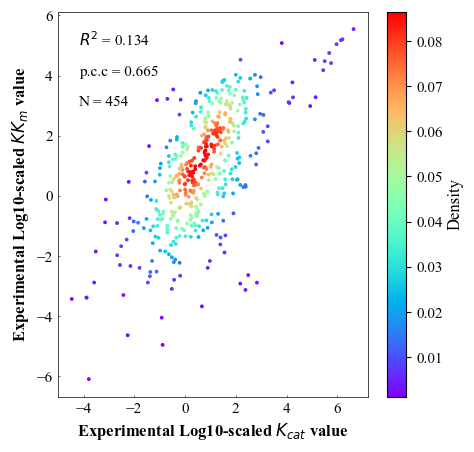

In [12]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
plt.figure(figsize=(5,5))
rc('font',**{'family':'Times New Roman'})
plt.rcParams['pdf.fonttype'] = 42
plt.tick_params(direction='in')
plt.tick_params(which='major',length=1.5)
plt.tick_params(which='major',width=0.4)
vstack = np.vstack([kcatValue,kkmValue])
experimental_predicted = gaussian_kde(vstack)(vstack)
ax = plt.scatter(x = kcatValue, y = kkmValue, c=experimental_predicted, s=3, cmap='rainbow')
cbar = plt.colorbar(ax)
cbar.ax.tick_params(labelsize=11)
cbar.set_label('Density', size=12)

plt.text(-4.2, 5, '$R^{2}$ = %.3f' % r2_score(kcatValue, kkmValue), fontweight ="normal", fontsize=11)
plt.text(-4.2, 4.0, 'p.c.c = %.3f' % correlation, fontweight ="normal", fontsize=11)
# plt.text(-4.2, 3.0, 'RMSE = %.3f' % Result['rmse'], fontweight ="normal", fontsize=11)
plt.text(-4.2, 3, f'N = {len(kkmValue)}', fontweight ="normal", fontsize=11)

plt.xlabel("Experimental Log10-scaled $K_{cat}$ value", fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12})
plt.ylabel('Experimental Log10-scaled $KK_{m}$ value',fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12})
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
# plt.ylim(-4)
# plt.xlim(-7)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)

plt.savefig(f"../Fig/SupplementaryFigure2-kcat-kkm.png", dpi=600, bbox_inches='tight')
plt.show()